# Interior Wall Rectangular Decomposition

Notebook ini mendemonstrasikan cara memecah instance interior wall yang masih berupa poligon kompleks menjadi sekumpulan segmen persegi panjang berbasis vektor. Seluruh langkah menggunakan operasi geometris (`shapely`) sehingga mudah divisualisasikan.

## 1. Setup
Impor dependensi yang dibutuhkan dan atur gaya plotting.

In [26]:
from __future__ import annotations

from collections import defaultdict
import json
from pathlib import Path
from typing import Iterable, List, Sequence, Tuple

import matplotlib.pyplot as plt
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon as MplPolygon
from shapely.geometry import GeometryCollection, MultiPolygon, Polygon, box, mapping, shape

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["axes.grid"] = False

## 2. Memuat data plan
Ganti `PLAN_JSON` bila ingin mencoba plan lain. Semua jalur relatif terhadap repo ini.

In [29]:
DATA_ROOT = Path("../output/resplan_json")
PLAN_JSON = DATA_ROOT / "plan_00000.json"

with PLAN_JSON.open() as f:
    plan = json.load(f)

interior_records = plan["instances"]["structural"]["interior_wall"]
print(f"Loaded {len(interior_records)} interior wall instances from {PLAN_JSON.name}")

exterior_records = plan["instances"]["structural"]["exterior_wall"]
print(f"Loaded {len(exterior_records)} exterior wall instances from {PLAN_JSON.name}")

Loaded 6 interior wall instances from plan_00000.json
Loaded 5 exterior wall instances from plan_00000.json


### Helper plotting utilities
Fungsi berikut mengubah poligon `shapely` menjadi patch Matplotlib sehingga tiap tahap bisa divisualisasikan.

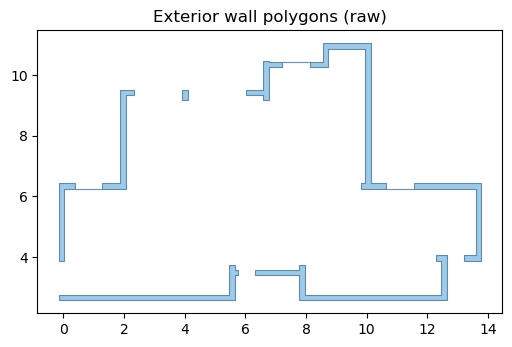

In [31]:
def record_to_geom(record: dict) -> Polygon | MultiPolygon:
    geom_dict = record.get("geom")
    if not geom_dict:
        raise ValueError("Record is missing GeoJSON geometry")
    return shape(geom_dict)


def _iter_polygons(geom: Polygon | MultiPolygon | GeometryCollection):
    if isinstance(geom, Polygon):
        yield geom
    elif isinstance(geom, MultiPolygon):
        for part in geom.geoms:
            yield part
    elif isinstance(geom, GeometryCollection):
        for sub in geom.geoms:
            if isinstance(sub, (Polygon, MultiPolygon)):
                yield from _iter_polygons(sub)


def add_polygons(ax, geometries: Sequence[Polygon | MultiPolygon], facecolor: str = "#5DA5DA", edgecolor: str = "#1B4F72", alpha: float = 0.6, linewidth: float = 0.8):
    patches: List[MplPolygon] = []
    for geom in geometries:
        for poly in _iter_polygons(geom):
            patches.append(MplPolygon(list(poly.exterior.coords)))
    collection = PatchCollection(patches, facecolor=facecolor, edgecolor=edgecolor, linewidth=linewidth, alpha=alpha)
    ax.add_collection(collection)
    ax.autoscale_view()
    ax.set_aspect("equal", adjustable="box")


def plot_geoms(geoms: Sequence[Polygon | MultiPolygon], title: str):
    fig, ax = plt.subplots()
    add_polygons(ax, geoms)
    ax.set_title(title)
    plt.show()


raw_polygons = [record_to_geom(rec) for rec in exterior_records]
plot_geoms(raw_polygons, "Exterior wall polygons (raw)")

## 3. Memeriksa salah satu interior wall berbentuk L
Pilih salah satu ID untuk dianalisis. Bila tidak tahu mana yang kompleks, gunakan ID yang jelas tidak persegi panjang.

Working on EX-0001 with area 2.878 m^2


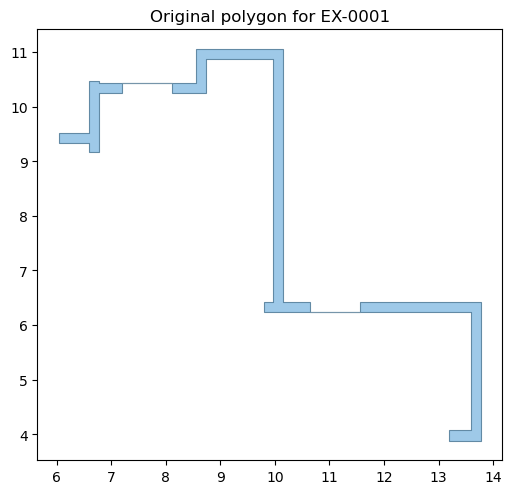

In [33]:
EXAMPLE_ID = "EX-0001"

example_rec = next((rec for rec in exterior_records if rec["id"] == EXAMPLE_ID), exterior_records[0])
example_geom = record_to_geom(example_rec)

print(f"Working on {example_rec['id']} with area {example_geom.area:.3f} m^2")
plot_geoms([example_geom], f"Original polygon for {example_rec['id']}")

## 4. Rectilinear decomposition dengan prioritas sumbu X
Algoritma:
1. Bentuk kisi ortogonal dari koordinat poligon.
2. Pecah poligon menjadi sel-sel kecil (grid rectangles).
3. Kelompokkan sel berdasarkan rentang X yang sama → gabungkan secara vertikal (sumbu Y).
4. Gabungkan antar kolom hanya bila rentang Y identik. Dengan cara ini bagian “kelebihan” tetap menjadi milik kolom (sumbu X), sehingga L-shape cukup menjadi dua persegi panjang tanpa ada tumpukan persegi di sudutnya.

Split EX-0001 into 14 rectangles


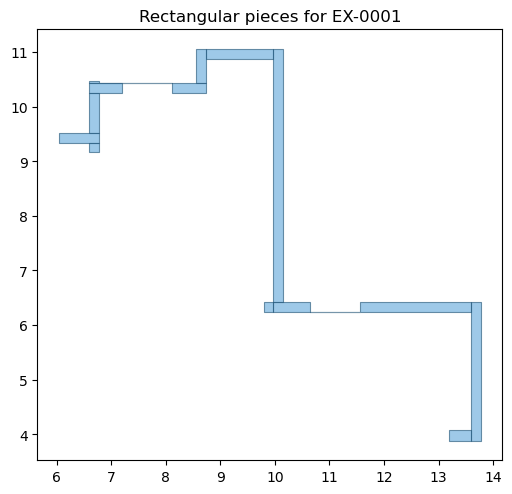

In [34]:
from shapely.geometry import LineString, LinearRing
from shapely.ops import split as shp_split


def is_axis_aligned_rectangle(poly: Polygon, tol: float = 1e-6) -> bool:
    coords = list(poly.exterior.coords)
    if len(coords) != 5:
        return False
    minx, miny, maxx, maxy = poly.bounds
    return abs(poly.area - (maxx - minx) * (maxy - miny)) <= tol


def find_reflex_vertex(poly: Polygon, tol: float = 1e-9):
    coords = list(poly.exterior.coords)
    if len(coords) < 4:
        return None
    ring = LinearRing(coords)
    is_ccw = ring.is_ccw
    coords = coords[:-1]
    n = len(coords)
    for i in range(n):
        ax, ay = coords[i - 1]
        bx, by = coords[i]
        cx, cy = coords[(i + 1) % n]
        v1x, v1y = bx - ax, by - ay
        v2x, v2y = cx - bx, cy - by
        cross = v1x * v2y - v1y * v2x
        if (is_ccw and cross < -tol) or ((not is_ccw) and cross > tol):
            return (bx, by)
    return None


def _build_splitter(poly: Polygon, reflex: tuple[float, float], axis: str):
    minx, miny, maxx, maxy = poly.bounds
    if axis == 'vertical':
        return LineString([(reflex[0], miny - 1), (reflex[0], maxy + 1)])
    return LineString([(minx - 1, reflex[1]), (maxx + 1, reflex[1])])


def split_polygon(poly: Polygon, tol: float = 1e-9) -> List[Polygon]:
    if is_axis_aligned_rectangle(poly):
        return [poly]

    reflex = find_reflex_vertex(poly, tol=tol)
    if reflex is None:
        return [poly]

    minx, miny, maxx, maxy = poly.bounds
    width = maxx - minx
    height = maxy - miny
    axis_order = ['vertical', 'horizontal'] if width >= height else ['horizontal', 'vertical']

    for axis in axis_order:
        splitter = _build_splitter(poly, reflex, axis)
        result = shp_split(poly, splitter)
        parts = [geom for geom in result.geoms if geom.area > tol]
        if len(parts) > 1:
            rectangles: List[Polygon] = []
            for part in parts:
                rectangles.extend(split_polygon(part, tol))
            return rectangles

    return [poly]


example_rects = split_polygon(example_geom)
print(f"Split {example_rec['id']} into {len(example_rects)} rectangles")
plot_geoms(example_rects, f"Rectangular pieces for {example_rec['id']}")

## 5. Menerapkan ke semua interior wall
Setiap poligon dipecah menjadi beberapa segmen dengan ID turunan `SOURCE_segXX`. Bagian ini juga memverifikasi luas sebelum dan sesudah pemecahan.

In [35]:
split_pieces = []
for rec in exterior_records:
    geom = record_to_geom(rec)
    tiles = split_polygon(geom)
    total = sum(tile.area for tile in tiles)
    if abs(total - geom.area) > 1e-6:
        print(f"Warning: area mismatch on {rec['id']} (orig={geom.area:.6f}, tiles={total:.6f})")
    for idx, tile in enumerate(tiles, start=1):
        split_pieces.append(
            {
                "source_id": rec["id"],
                "id": f"{rec['id']}_seg{idx:02d}",
                "geom": tile,
                "area": tile.area,
            }
        )

print(f"Generated {len(split_pieces)} rectangular pieces from {len(exterior_records)} interior walls")

Generated 28 rectangular pieces from 5 interior walls


### Visualisasi gabungan setelah pemecahan

/var/folders/_r/pq1zmsn93blcqytv44mnlsrm0000gn/T/ipykernel_1296/1035083236.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20", len(pieces))


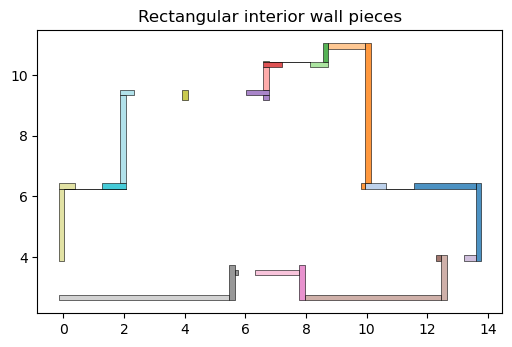

In [36]:
def plot_split_result(pieces: Sequence[dict]):
    fig, ax = plt.subplots(figsize=(6, 6))
    colors = plt.cm.get_cmap("tab20", len(pieces))
    for idx, piece in enumerate(pieces):
        add_polygons(
            ax,
            [piece["geom"]],
            facecolor=colors(idx),
            edgecolor="black",
            alpha=0.8,
            linewidth=0.5,
        )
    ax.set_title("Rectangular interior wall pieces")
    plt.show()

plot_split_result(split_pieces)

## 6. Menyiapkan output baru (opsional)
Contoh berikut menunjukkan cara mengubah hasil potongan kembali menjadi struktur JSON (GeoJSON) sehingga dapat menggantikan `instances.structural.interior_wall` sebelum diekspor ke TTL.

In [ ]:
def piece_to_record(piece: dict) -> dict:
    return {
        "id": piece["id"],
        "type": "interior_wall",
        "geom": mapping(piece["geom"]),
        "props": {
            "area": float(piece["area"]),
            "bbox": list(piece["geom"].bounds),
        },
        "source_interior_id": piece["source_id"],
    }

split_records = [piece_to_record(piece) for piece in split_pieces]
print(split_records[0])

# Untuk menulis kembali ke disk, aktifkan kode berikut:
# output_path = PLAN_JSON.with_name(PLAN_JSON.stem + "_rectified.json")
# plan_copy = json.loads(json.dumps(plan))  # deep copy via round-trip
# plan_copy["instances"]["structural"]["interior_wall"] = split_records
# output_path.write_text(json.dumps(plan_copy, indent=2))
# print(f"Saved updated plan to {output_path}")

## 7. Langkah berikutnya
- Gunakan `split_records` untuk menghitung ulang relasi (`thesis_package.geometry.compute_relations`).
- Masukkan JSON baru ke pipeline konversi TTL (`ontology/json_to_ttl.py`).
- Bandingkan hasil visualisasi di `Notebooks/visualization.ipynb` sebelum dan sesudah pemecahan.